In [15]:
import sys
from pathlib import Path
E9path = Path("C:/", "Users", "ken92", "Documents", "Studies", "E5", "simulation", "E9_simulations")
if str(E9path) not in sys.path:
    sys.path.insert(1, str(E9path))
import E9_fn.E9_constants as E9c
from E9_fn import util

import numpy as np
from scipy.optimize import least_squares, root_scalar
import matplotlib.pyplot as plt

In [2]:
W = 1
L_S = 100
L_R = 100

In [3]:
def f0(mu, T):
    f_raw = util.fermi_stat(0, T, mu)
    return np.nan_to_num(f_raw)

def N_toy_S(mu, W = 1, L_S = 100):
    return (L_S / W) * mu

def N_toy_R(mu, T, L_R = 100):
    n_R = util.fermi_stat(0, T, mu)
    return L_R * n_R

def N_toy(mu, T, W = 1, L_S = 100, L_R = 100):
    return N_toy_S(mu, W, L_S) + N_toy_R(mu, T, L_R)

def n_toy(mu, T, W = 1, L_S = 100, L_R = 100):
    return N_toy(mu, T, W, L_S, L_R) / (L_S + L_R)

def S_toy_S(T, W = 1, L_S = 100):
    return (np.pi**2 / 3) * (L_S / W) * T

def S_toy_R(mu, T, L_R = 100):
    n_R = util.fermi_stat(0, T, mu)
    S_raw = - L_R * ((1 - n_R) * np.log(1 - n_R) + n_R * np.log(n_R))
    return np.nan_to_num(S_raw)

def S_toy(mu, T, W = 1, L_S = 100, L_R = 100):
    return S_toy_S(T, W, L_S) + S_toy_R(mu, T, L_R)

def s_toy(mu, T, W = 1, L_S = 100, L_R = 100):
    return S_toy(mu, T, W, L_S, L_R) / (L_S + L_R)

In [24]:
s_joint = 0.2
def s_toy_mu0(n_R):
    return - ((1 - n_R) * np.log(1 - n_R) + n_R * np.log(n_R)) / 2 - s_joint
sol_low = root_scalar(s_toy_mu0, bracket = (0.01, 0.5))
sol_high = root_scalar(s_toy_mu0, bracket = (0.5, 0.99))
print(f"r_R = ({sol_low.root}, {sol_high.root})")

r_R = (0.13728271818233093, 0.862717281817669)


In [4]:
mu_grid = np.linspace(-2, 2, 101)
T_grid = np.linspace(0, 1, 101)

mu_mesh, T_mesh = np.meshgrid(mu_grid, T_grid)

C:\Users\ken92\AppData\Local\Temp\ipykernel_1972\3946974243.py:23: RuntimeWarning: divide by zero encountered in log
  S_raw = - L_R * ((1 - n_R) * np.log(1 - n_R) + n_R * np.log(n_R))
C:\Users\ken92\AppData\Local\Temp\ipykernel_1972\3946974243.py:23: RuntimeWarning: invalid value encountered in multiply
  S_raw = - L_R * ((1 - n_R) * np.log(1 - n_R) + n_R * np.log(n_R))


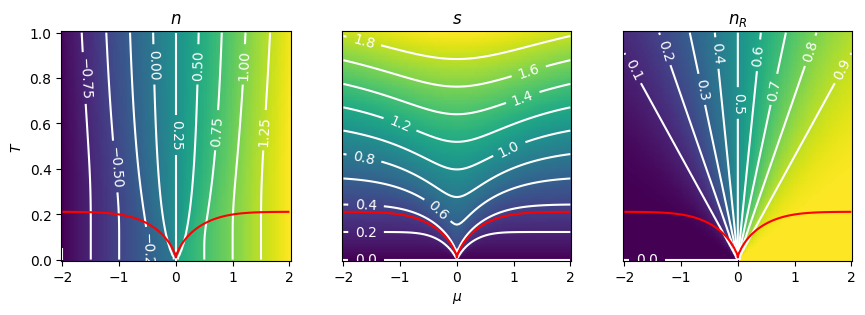

In [ ]:
fig_NS, axes_NS = plt.subplots(1, 3, figsize = (9, 3))

for ax, fn, title in zip(axes_NS, [n_toy, s_toy, f0], [r"$n$", r"$s$", r"$n_R$"]):
    ax.set_box_aspect(1)
    vals = fn(mu_mesh, T_mesh)
    # Rasterization is required to prevent the white grids when converting to pdf (also makes files smaller)
    ax.pcolormesh(mu_mesh, T_mesh, vals, rasterized = True)
    cntr = ax.contour(mu_mesh, T_mesh, vals, colors = "white", linestyles = "solid", levels = 11)
    ax.clabel(cntr, inline = True)
    # if title == r"$s$":
    #     cntr_T0 = ax.contour(mu_mesh, T_mesh, vals, colors = "red", linestyles = "solid", levels = [np.log(2) / 2])
        # ax.clabel(cntr_T0, inline = True)
    cntr_T0 = ax.contour(mu_mesh, T_mesh, s_toy(mu_mesh, T_mesh), colors = "red", linestyles = "solid", levels = [np.log(2) / 2])
    ax.set_title(title)

axes_NS[0].set_ylabel(r"$T$")
axes_NS[1].set_yticks([])
axes_NS[1].set_xlabel(r"$\mu$")
axes_NS[2].set_yticks([])
fig_NS.tight_layout()

thesis_fig_path = Path(r"C:\Users\ken92\Documents\Studies\E5\Theses\figures\flatband")
file_full_path = Path(thesis_fig_path, "toy_NS_of_muT_plots.pdf")
# fig_NS.savefig(file_full_path, dpi = 300, bbox_inches='tight')

In [ ]:
N_range = np.arange(-50, 151, 5)
S_low = 30  # some low total entropy, should be less than the total entropy capacity
S_high = 80 # some high total entropy, should be more than the total entropy capacity
Sbar = 100 * np.log(2)
assert S_low < Sbar < S_high

In [7]:
def solve_for_all_N(N_range, S_target, initial_guess=(-1.0, 0.3)):
    """
    Solves for mu and T across a range of N values using 
    a linear extrapolation warm-start to punch through T=0 singularities.
    """
    mu_results = np.zeros(len(N_range))
    T_results = np.zeros(len(N_range))
    
    current_guess = initial_guess
    prev_sol_x = None  # Will hold the solution from two steps ago
    
    bounds = ([-np.inf, -np.inf], [np.inf, np.inf])

    for i, N_target in enumerate(N_range):
        def residuals(vars):
            mu, T = vars
            err_N = N_toy(mu, T) - N_target
            err_S = S_toy(mu, T) - S_target
            return [err_N, err_S]
        
        sol = least_squares(residuals, jac='3-point', x0=current_guess, bounds=bounds,
                            ftol=1e-12, xtol=1e-12)
        
        # STRICT CHECK: Ensure it actually solved the equations, not just hit a dead zone
        if sol.success and np.max(np.abs(sol.fun)) < 1e-4:
            mu_results[i] = sol.x[0]
            T_results[i] = sol.x[1]
            
            # THE WARM-START FIX: Linear Extrapolation
            if prev_sol_x is not None:
                # Predict the next point by continuing the previous slope.
                # This naturally jumps over the T=0 line.
                current_guess = sol.x + (sol.x - prev_sol_x)
            else:
                current_guess = sol.x.copy()
            
            # Store the current valid solution for the next loop's extrapolation
            prev_sol_x = sol.x.copy()
            
        else:
            print(f"Solver failed or trapped at N = {N_target}. Residuals: {sol.fun}")
            mu_results[i] = np.nan
            T_results[i] = np.nan
            
            # THE KICK: If it does get trapped, slightly perturb the guess 
            # to push it out of the dead zone for the next iteration
            current_guess = current_guess + np.array([0.1, 0.1])
            
    return mu_results, T_results

In [8]:
mu_sols_low, T_sols_low = solve_for_all_N(N_range, S_low, initial_guess=(-1.0, 0.3))
n_S_low = N_toy_S(mu_sols_low) / 100
s_S_low = S_toy_S(T_sols_low) / 100
n_R_low = N_toy_R(mu_sols_low, T_sols_low) / 100
s_R_low = S_toy_R(mu_sols_low, T_sols_low) / 100
mu_sols_high, T_sols_high = solve_for_all_N(N_range, S_high, initial_guess=(-1.0, 0.3))

In [ ]:
# Make the region where S < 0 transparent
T_neg_low = (T_sols_low < 0)
N_neg_low = N_range[T_neg_low]
n_S_mix = np.zeros_like(N_neg_low)
s_S_mix = np.zeros_like(N_neg_low)
n_R1 = N_neg_low[0] / 100
n_R2 = N_neg_low[-1] / 100

alphas_low = np.ones_like(N_range, dtype = float)
alphas_low[T_neg_low] = 0.2

# Propose an alternative - mixed phase
n_R_mix = n_R1 + (n_R2 - n_R1) * np.linspace(0, 1, len(N_neg_low))
s_R_mix = np.ones_like(N_neg_low) * S_low / 100

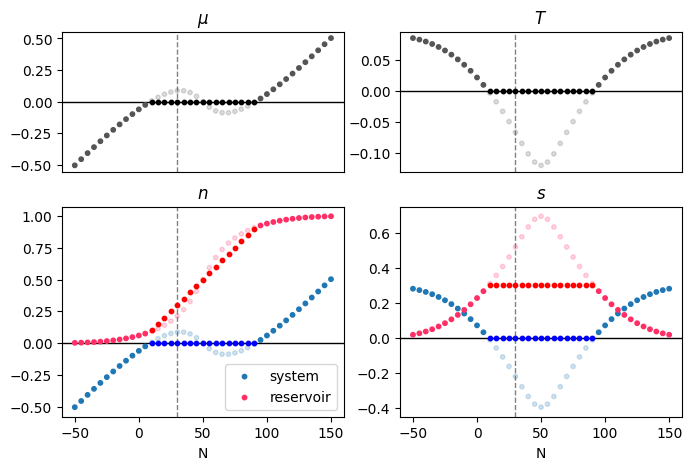

In [ ]:
fig_Nscan, axes_Nscan = plt.subplots(2, 2, figsize = (8, 5), height_ratios = [2, 3])

for ax, data, title in zip(axes_Nscan[0],
                           [mu_sols_low, T_sols_low],
                           [r"$\mu$", r"$T$"]):
    ax.scatter(N_range, data, s = 10, color = "#555555", alpha = alphas_low)
    ax.scatter(N_neg_low, np.zeros_like(N_neg_low), s = 10, color = "black")
    ax.axhline(0, 1, 0, color = "black", linewidth = 1, zorder = 0)
    ax.axvline(30, 0, 1, color = "gray", linewidth = 1, linestyle = "--", zorder = 0)   # eyeballed inflection point of mu
    ax.set_title(title)
    ax.set_xticks([])

for ax, data_S, data_R, mix_S, mix_R, title in zip(axes_Nscan[1],
                           [n_S_low, s_S_low],
                           [n_R_low, s_R_low],
                           [n_S_mix, s_S_mix],
                           [n_R_mix, s_R_mix],
                           [r"$n$", r"$s$"]):
    ax.axhline(0, 1, 0, color = "black", linewidth = 1, zorder = 0)
    ax.scatter(N_range, data_S, s = 10, color = "#1f77b4", alpha = alphas_low, label = "system")
    ax.scatter(N_range, data_R, s = 10, color = "#ff2f66", alpha = alphas_low, label = "reservoir")
    ax.scatter(N_neg_low, mix_S, s = 10, color = "blue")
    ax.scatter(N_neg_low, mix_R, s = 10, color = "red")
    ax.axvline(30, 0, 1, color = "gray", linewidth = 1, linestyle = "--", zorder = 0)   # eyeballed inflection point of mu
    ax.set_title(title)
    ax.set_xlabel(r"N")
axes_Nscan[1][0].legend()

file_full_path = Path(thesis_fig_path, "toy_ns_in_subregion.pdf")
# fig_Nscan.savefig(file_full_path, dpi = 300, bbox_inches='tight')

This one is exactly Dan's plot.

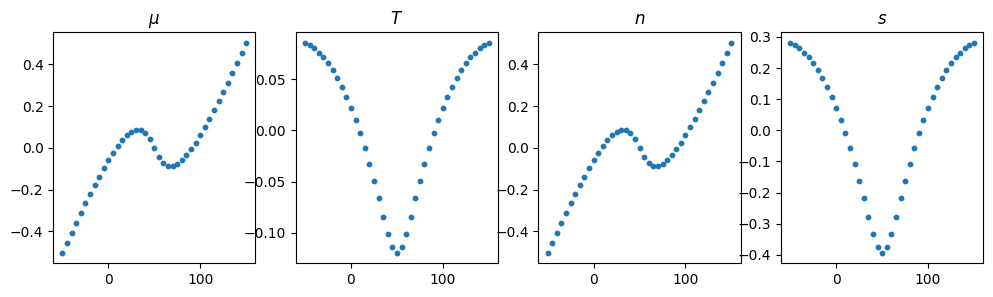

In [27]:
fig_Nscan2, axes_Nscan2 = plt.subplots(1, 4, figsize = (12, 3))
for ax, data, title in zip(axes_Nscan2.flatten(),
                           [mu_sols_low, T_sols_low, n_S_low, s_S_low],
                           [r"$\mu$", r"$T$", r"$n$", r"$s$"]):
    ax.scatter(N_range, data, s = 10)
    ax.set_title(title)